# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
from functions import *

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [2]:
data = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')
data.head()

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0


## Behavioral segmentation

In [3]:
behavioral_data = data[["TotalFlights", "TotalPointsAccumulated", "TotalDistance", "RecencyInMonths", "Days_in_prog",
                        
                        "Pct_Spend_Month_1", "Pct_Spend_Month_2", "Pct_Spend_Month_3", "Pct_Spend_Month_4", "Pct_Spend_Month_5", 
                        "Pct_Spend_Month_6", "Pct_Spend_Month_7", "Pct_Spend_Month_8", "Pct_Spend_Month_9", "Pct_Spend_Month_10", 
                        "Pct_Spend_Month_11", "Pct_Spend_Month_12",
                        
                        "PctFlightsWithCompanions",	"PctPointsSpent"]]

Total Spends per month will not be used as they become redundant when gathers with the percentages per month.

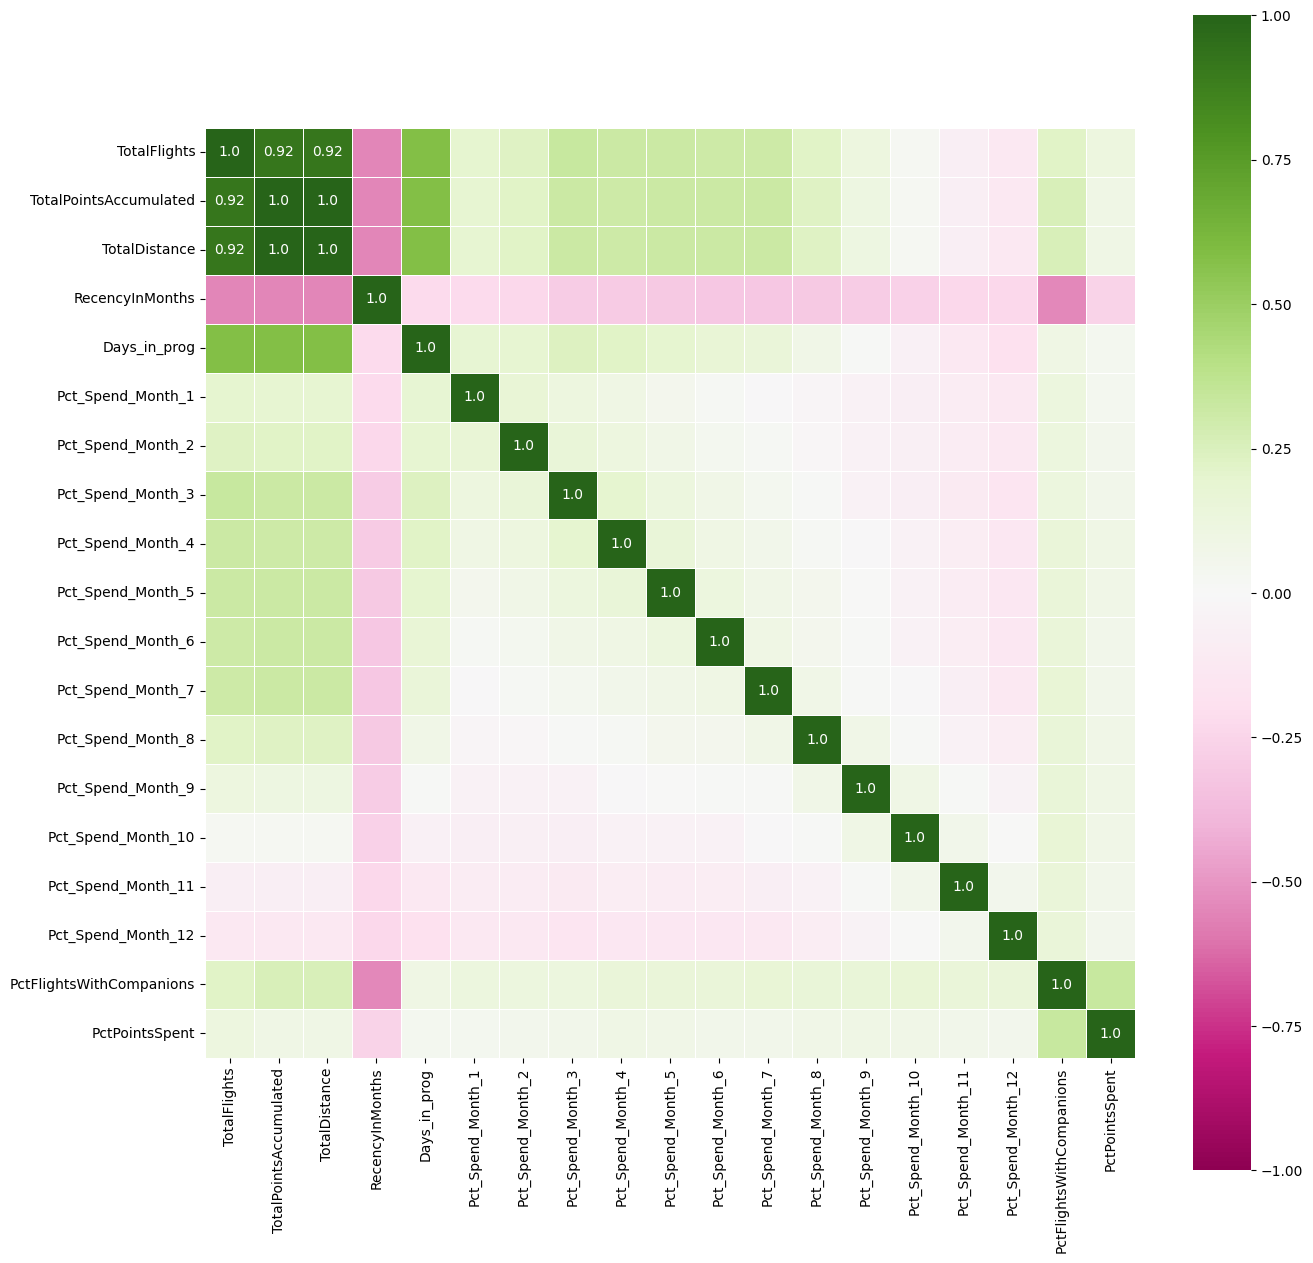

In [4]:
correlation_matrix(behavioral_data, 0.7, 15, 15)

We will keep TotalPointsAccumulated, because it's the most comprehensive engagement metric, out of the three highly correlated features.

In [5]:
behavioral_data = behavioral_data.drop(columns = ["TotalFlights", "TotalDistance"])

In [6]:
behavioral_data.to_csv("../data/clustering_data/behavioral_data.csv")

In [4]:
behavioral_data = behavioral_data.copy()

In [5]:
behavioral_data

,TotalDistance,RecencyInMonths,Days_in_prog,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12
Loyalty#,,,,,,,,,,,,,,,
100011,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100012,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100013,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100014,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100015,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999996,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999997,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695


In [6]:
behavioral_data_st_scl = StandardScaler().fit_transform(behavioral_data)
behavioral_data_mm_scl = MinMaxScaler().fit_transform(behavioral_data)
behavioral_data_rb_scl = RobustScaler().fit_transform(behavioral_data)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

### Behavioral Data

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

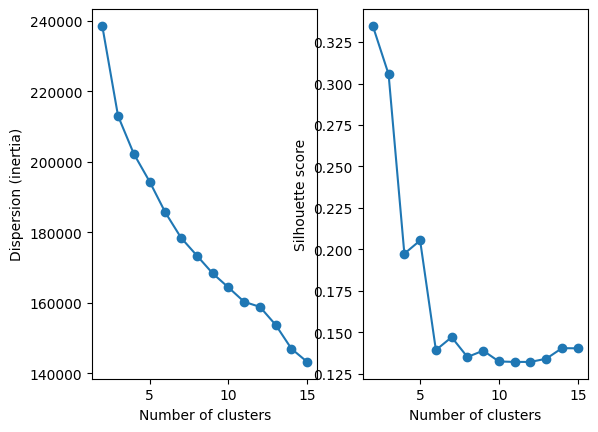

In [14]:
plot_inertia_and_silhouette(behavioral_data_st_scl)

In [7]:
kmeans_st_scl = KMeans(n_clusters=4, random_state=42).fit(behavioral_data_st_scl)
data['st_scaled_km_cluster4'] = kmeans_st_scl.predict(behavioral_data_st_scl)
behavioral_data['st_scaled_km_cluster4'] = kmeans_st_scl.predict(behavioral_data_st_scl)

### Hierarchichal - Ward

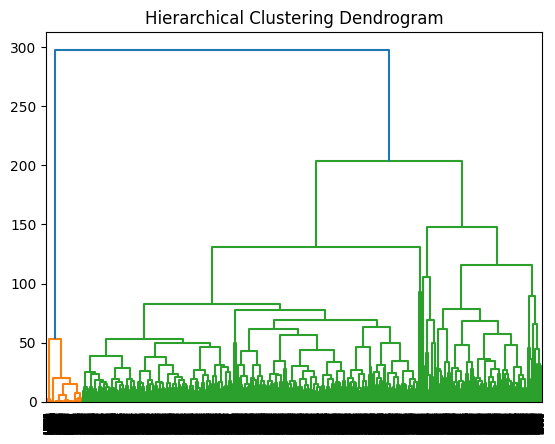

In [16]:
plot_dendrogram(behavioral_data_st_scl, 'ward')

In [8]:
data['st_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(behavioral_data_st_scl)

behavioral_data['st_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(behavioral_data_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

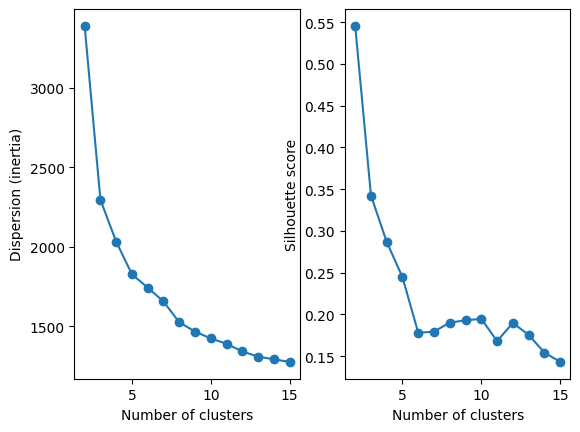

In [18]:
plot_inertia_and_silhouette(behavioral_data_mm_scl)

In [9]:
kmeans_mm_scl = KMeans(n_clusters=4, random_state=42).fit(behavioral_data_mm_scl)
data['mm_scaled_km_cluster4'] = kmeans_mm_scl.predict(behavioral_data_mm_scl)
behavioral_data['mm_scaled_km_cluster4'] = kmeans_mm_scl.predict(behavioral_data_mm_scl)

### Hierarchichal - Ward

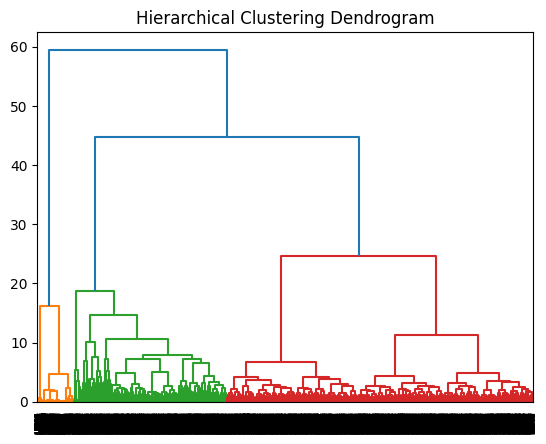

In [20]:
plot_dendrogram(behavioral_data_mm_scl, 'ward')

In [10]:
data['mm_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(behavioral_data_mm_scl)

behavioral_data['mm_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(behavioral_data_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

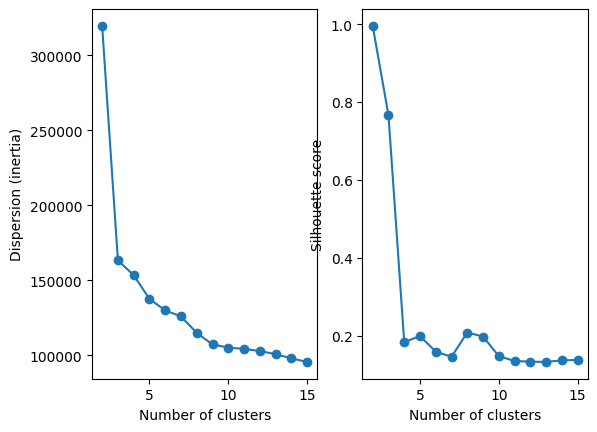

In [22]:
plot_inertia_and_silhouette(behavioral_data_rb_scl)

In [11]:
kmeans_rb_scl = KMeans(n_clusters=4, random_state=42).fit(behavioral_data_rb_scl)
data['rb_scaled_km_cluster4'] = kmeans_rb_scl.predict(behavioral_data_rb_scl)
behavioral_data['rb_scaled_km_cluster4'] = kmeans_rb_scl.predict(behavioral_data_rb_scl)

### Hierarchichal - Ward

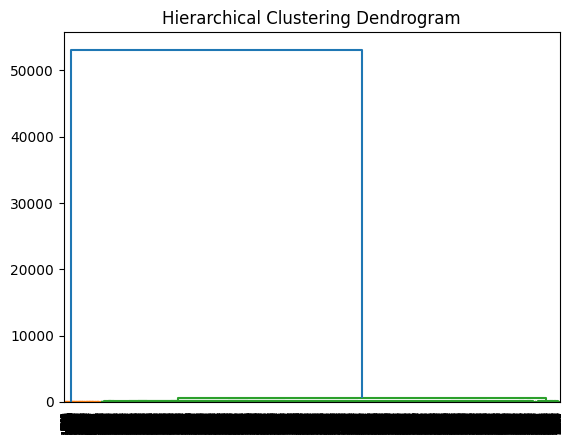

In [24]:
plot_dendrogram(behavioral_data_rb_scl, 'ward')

In [12]:
data['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_rb_scl)

behavioral_data['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_rb_scl)

# <span style="color:#0097b2">1. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization 1

In [13]:
clusters_km = ['st_scaled_km_cluster4', 'mm_scaled_km_cluster4', 'rb_scaled_km_cluster4']

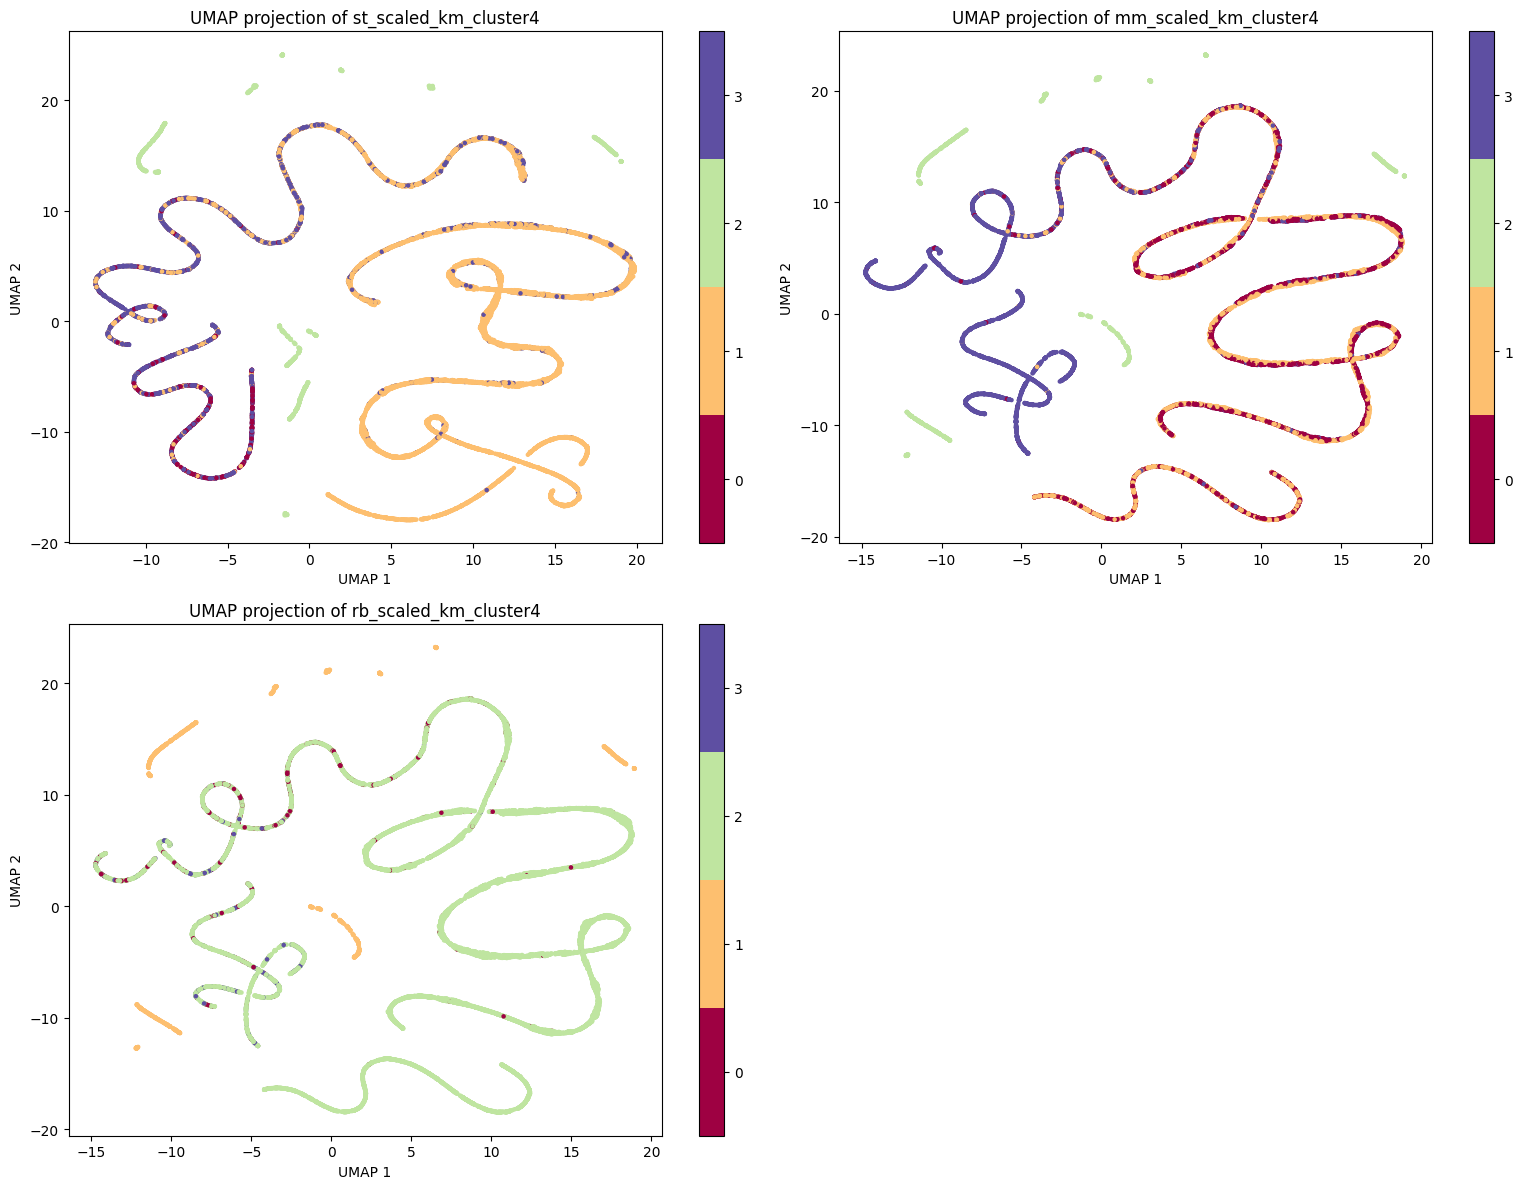

In [14]:
plot_umap_projections(behavioral_data, clusters_km)

In [15]:
groupby_mean(behavioral_data, 'rb_scaled_km_cluster4', n_features= 16)

rb_scaled_km_cluster4,0,1,2,3
TotalDistance,206104.361710,0.000000,326393.847745,95482.151887
RecencyInMonths,11.707717,999.000000,1.480511,20.693559
Days_in_prog,684.916357,582.224786,1171.357213,624.933962
Pct_Spend_Month_1,0.063650,0.000514,0.053699,0.286253
Pct_Spend_Month_2,0.060322,0.000527,0.053673,0.223560
Pct_Spend_Month_3,0.088906,0.000721,0.072249,0.163336
Pct_Spend_Month_4,0.070175,0.000646,0.064317,0.111783
Pct_Spend_Month_5,0.087071,0.000776,0.077046,0.083509
Pct_Spend_Month_6,0.104055,0.000989,0.096006,0.078610
Pct_Spend_Month_7,0.093338,0.001051,0.102901,0.044915


In [16]:
cluster_ward = ['st_scaled_ward_cluster3', 'mm_scaled_ward_cluster3', 'rb_scaled_ward_cluster2']

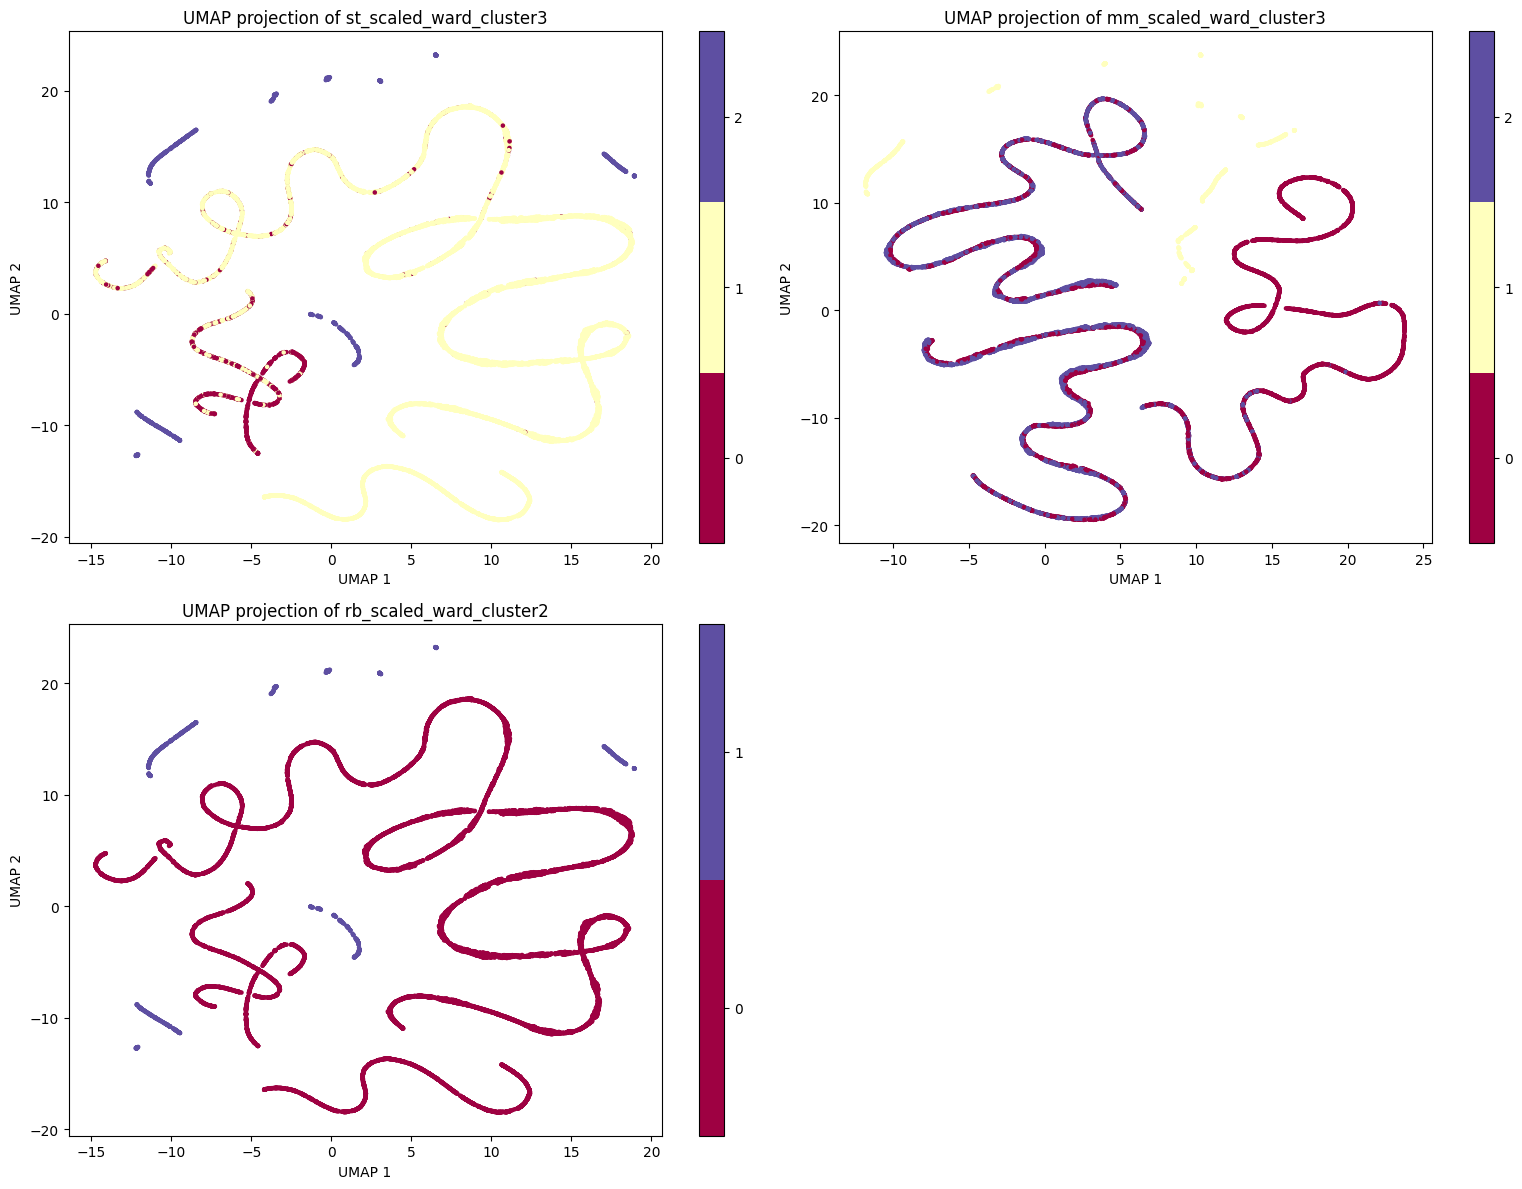

In [17]:
plot_umap_projections(behavioral_data, cluster_ward)

In [18]:
groupby_mean(behavioral_data, 'st_scaled_ward_cluster3', n_features= 16)

st_scaled_ward_cluster3,0,1,2
TotalDistance,79927.786970,345791.281005,0.000000
RecencyInMonths,1.870557,2.290590,999.000000
Days_in_prog,234.946527,1251.651834,582.224786
Pct_Spend_Month_1,0.007901,0.065051,0.000514
Pct_Spend_Month_2,0.009449,0.063234,0.000527
Pct_Spend_Month_3,0.006443,0.082949,0.000721
Pct_Spend_Month_4,0.006539,0.072601,0.000646
Pct_Spend_Month_5,0.010843,0.085544,0.000776
Pct_Spend_Month_6,0.020606,0.104970,0.000989
Pct_Spend_Month_7,0.058363,0.106508,0.001051


- Cluster 1 - (Cancelled Program and Don't fly)

#### Cluster Extraction 1

In [19]:
# Filter the DataFrame based on cluster labels
no_flights = data[data['rb_scaled_km_cluster4'] == 1]

In [20]:
no_flights

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster4,st_scaled_ward_cluster3,mm_scaled_km_cluster4,mm_scaled_ward_cluster3,rb_scaled_km_cluster4,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,1,0,2,2,2,1,1,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,1,2,2,2,1,1,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,1,0,2,2,2,1,1,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,1,0,2,2,2,1,1,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,1,0,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,1,0,2,2,2,1,1,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,1,2,2,2,1,1,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,1,0,2,2,2,1,1,1


In [21]:
# List of cluster labels to exclude
exclude_clusters = [1]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered1 = data[~data['rb_scaled_km_cluster4'].isin(exclude_clusters)]

In [22]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster4,st_scaled_ward_cluster3,mm_scaled_km_cluster4,mm_scaled_ward_cluster3,rb_scaled_km_cluster4,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,1,1,0,0,2,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,0,0,0,1,1,1,1,2,2,0
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,0,1,0,0,1,1,0,0,2,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,0,1,0,3,1,0,2,2,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,0,0,1,1,1,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,0,0,1,0,1,1,3,0,3,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,1,0,1,1,1,2,2,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,0,0,1,0,3,1,3,0,2,0


In [23]:
data_filtered1 = data_filtered1.iloc[:, :-6]
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,1,0,0,0,0,0,1,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,0,1,0,0,0,0,1,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,1,0,0,0,0,0,1,0


In [24]:
behavioral_data = behavioral_data.iloc[:, :-6]
behavioral_data

,TotalDistance,RecencyInMonths,Days_in_prog,Pct_Spend_Month_1,Pct_Spend_Month_2,Pct_Spend_Month_3,Pct_Spend_Month_4,Pct_Spend_Month_5,Pct_Spend_Month_6,Pct_Spend_Month_7,Pct_Spend_Month_8,Pct_Spend_Month_9,Pct_Spend_Month_10,Pct_Spend_Month_11,Pct_Spend_Month_12
Loyalty#,,,,,,,,,,,,,,,
100011,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100012,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100013,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100014,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
100015,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999996,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695
999997,0.0,999.0,0.0,0.038995,0.040009,0.054678,0.048966,0.058884,0.07504,0.079692,0.073238,0.061647,0.059436,0.05796,0.079695


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

In [25]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999891,59732.0,3745.37,0,0,245.0,1,2019,5,3,1.9,...,1,0,1,0,0,0,0,0,1,0
999902,0.0,7290.07,0,0,1681.0,0,2017,5,1,267.1,...,0,0,0,1,0,0,0,0,1,0
999940,21542.0,20266.50,0,0,523.0,0,2020,7,4,87.5,...,1,0,1,0,0,0,0,0,1,0


In [26]:
data_filtered11 = data_filtered1.copy()
behavioral_data_1 = data_filtered11[behavioral_data.columns.to_list()]

In [27]:
behavioral_data_1_st_scl = StandardScaler().fit_transform(behavioral_data_1)
behavioral_data_1_mm_scl = MinMaxScaler().fit_transform(behavioral_data_1)
behavioral_data_1_rb_scl = RobustScaler().fit_transform(behavioral_data_1)

#### Cluster Modelling 2

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

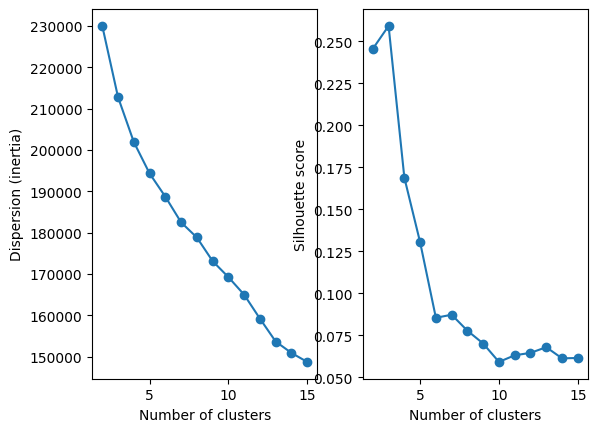

In [56]:
plot_inertia_and_silhouette(behavioral_data_1_st_scl)

In [28]:
kmeans_st_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_1_st_scl)
data_filtered11['st_scaled_km_cluster3'] = kmeans_st_scl.predict(behavioral_data_1_st_scl)
behavioral_data_1['st_scaled_km_cluster3'] = kmeans_st_scl.predict(behavioral_data_1_st_scl)

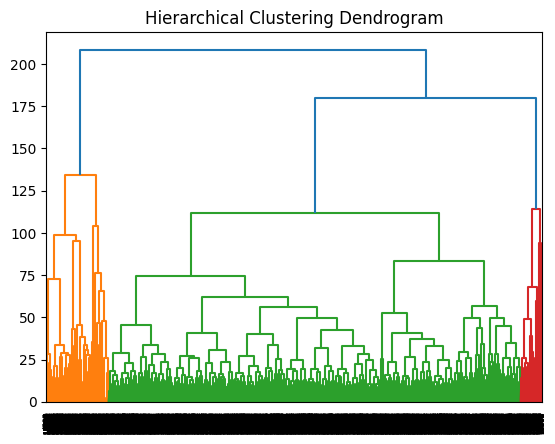

In [57]:
plot_dendrogram(behavioral_data_1_st_scl, 'ward')

In [29]:
data_filtered11['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_st_scl)

behavioral_data_1['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Min Max Scaling</h3>

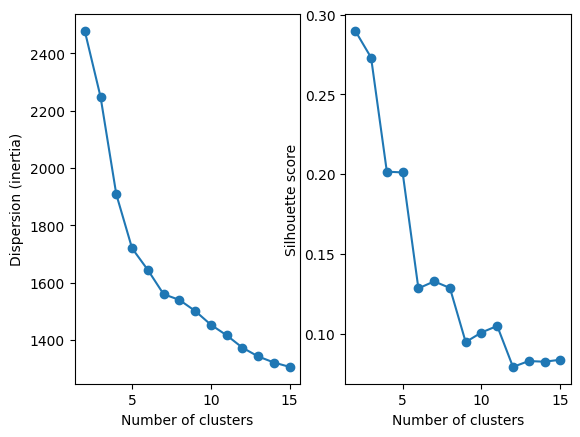

In [58]:
plot_inertia_and_silhouette(behavioral_data_1_mm_scl)

In [30]:
kmeans_mm_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_1_mm_scl)
data_filtered11['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_1_mm_scl)
behavioral_data_1['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_1_mm_scl)

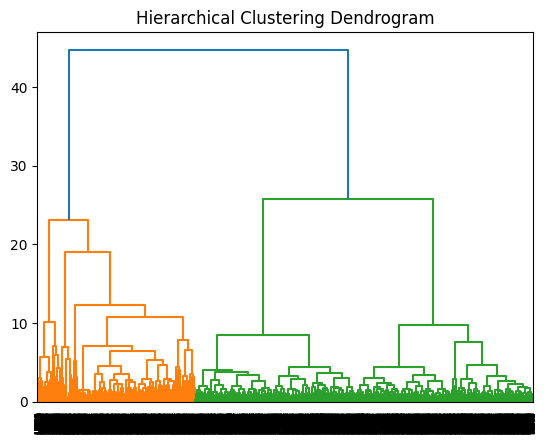

In [59]:
plot_dendrogram(behavioral_data_1_mm_scl, 'ward')

In [31]:
data_filtered11['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_mm_scl)


behavioral_data_1['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

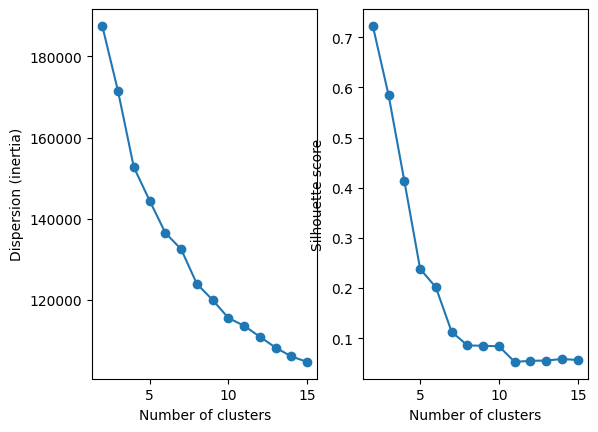

In [60]:
plot_inertia_and_silhouette(behavioral_data_1_rb_scl)

In [32]:
kmeans_rb_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_1_rb_scl)
data_filtered11['rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(behavioral_data_1_rb_scl)
behavioral_data_1['rb_scaled_km_cluster2'] = kmeans_rb_scl.predict(behavioral_data_1_rb_scl)

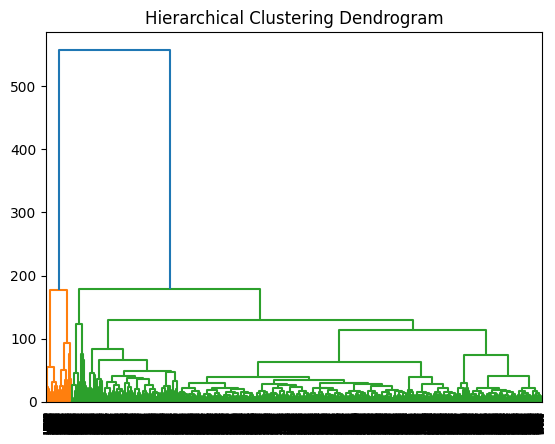

In [61]:
plot_dendrogram(behavioral_data_1_rb_scl, 'ward')

In [33]:
data_filtered11['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_rb_scl)

behavioral_data_1['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_1_rb_scl)

#### Cluster Visualization 2

In [34]:
cluster_filter1 = ["st_scaled_km_cluster3",	"st_scaled_ward_cluster2", 
                   "mm_scaled_km_cluster3", "mm_scaled_ward_cluster2",
                   "rb_scaled_km_cluster2",	"rb_scaled_ward_cluster2"]

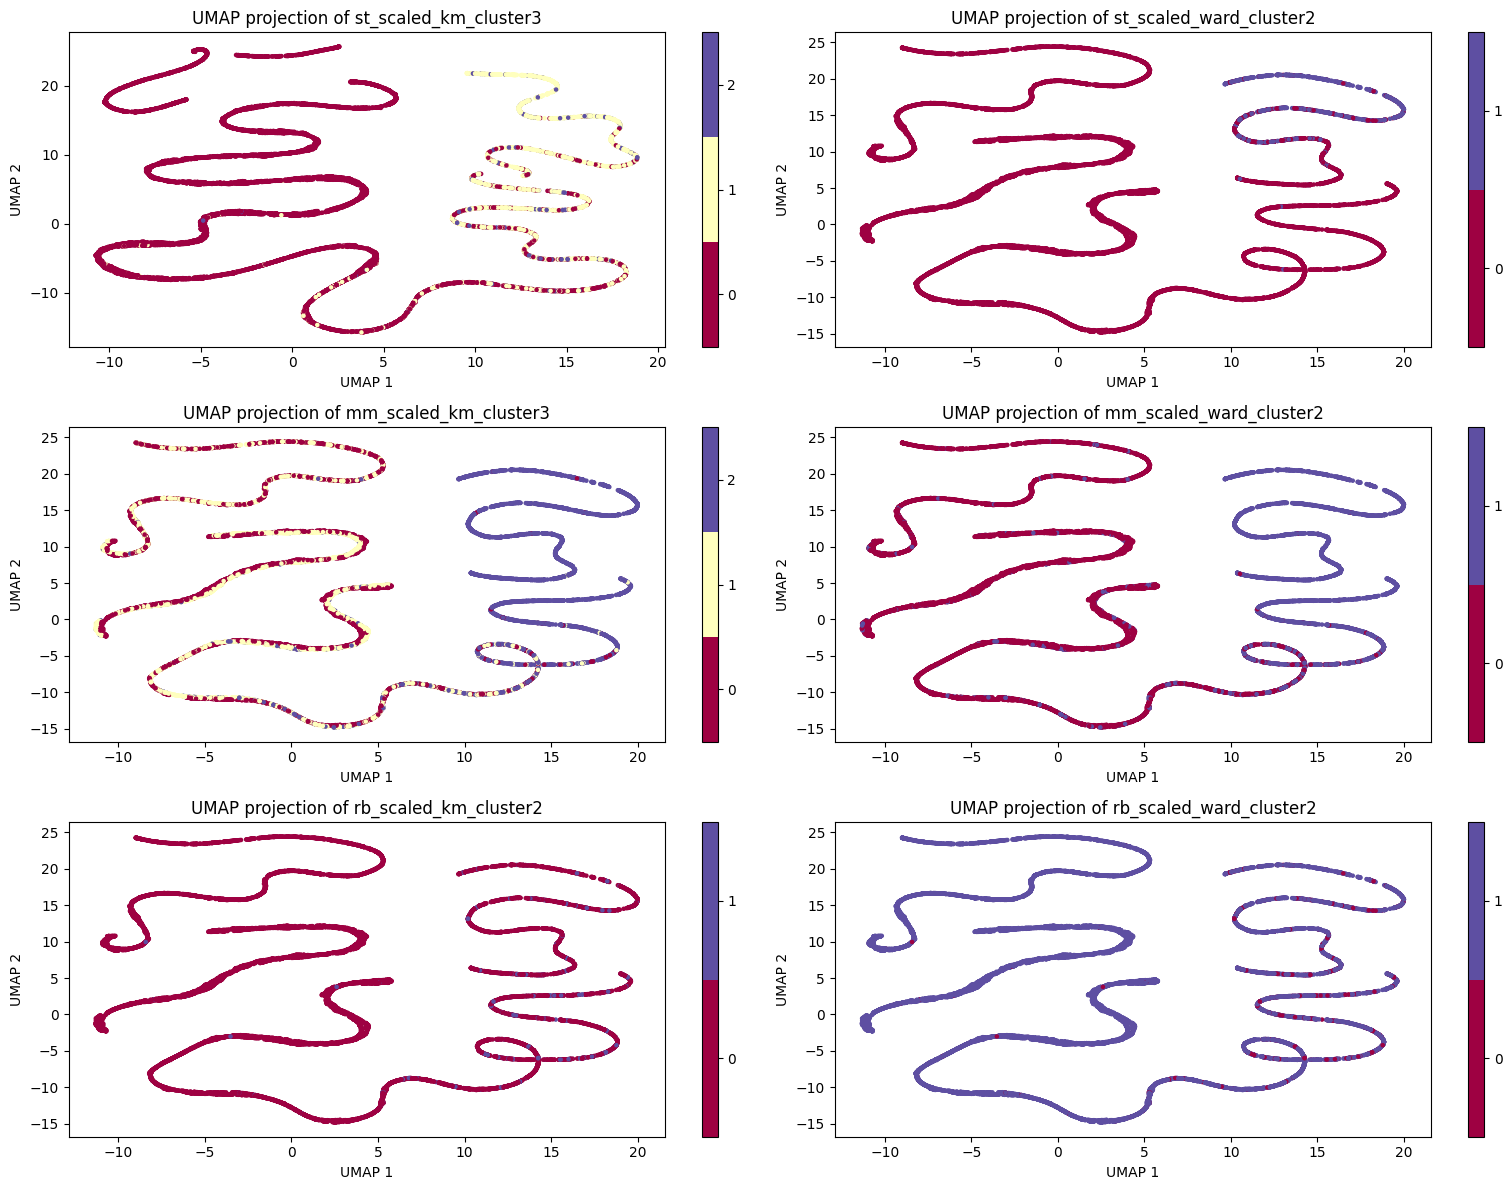

In [35]:
plot_umap_projections(behavioral_data_1, cluster_filter1)

In [36]:
groupby_mean(behavioral_data_1, 'mm_scaled_ward_cluster2', n_features= 16)

mm_scaled_ward_cluster2,0,1
TotalDistance,390275.165709,156328.743992
RecencyInMonths,1.494072,3.902975
Days_in_prog,1503.207124,347.497360
Pct_Spend_Month_1,0.064122,0.047461
Pct_Spend_Month_2,0.063096,0.045057
Pct_Spend_Month_3,0.083608,0.055208
Pct_Spend_Month_4,0.073086,0.048830
Pct_Spend_Month_5,0.085052,0.060962
Pct_Spend_Month_6,0.104279,0.077507
Pct_Spend_Month_7,0.109445,0.083487


- Cluster 1 - More recent customers, as they have less days in the program, but they spent most of their flights on the last 4 months (from 9 to 12)

#### Cluster Extraction 2

In [37]:
# Filter the DataFrame based on cluster labels
new_9_to_12_travelers = data_filtered11[data_filtered11['mm_scaled_ward_cluster2'] == 1]
len(new_9_to_12_travelers)

4735

In [38]:
# List of cluster labels to exclude
exclude_clusters = [1]

# Filter the original dataset to exclude rows with specified cluster labels
data_filter2 = data_filtered11[~data_filtered11['mm_scaled_ward_cluster2'].isin(exclude_clusters)]

In [39]:
data_filter2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster3,st_scaled_ward_cluster2,mm_scaled_km_cluster3,mm_scaled_ward_cluster2,rb_scaled_km_cluster2,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,1,0,0,1
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,0,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,0,1,0,0,0,0,1,0,0,1
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,0,1,0,0,0,1,0,0,1
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999513,83560.0,27064.46,0,0,1627.0,0,2017,7,0,155.6,...,0,0,1,0,0,0,0,0,0,1
999524,0.0,14325.15,0,0,1329.0,0,2018,5,4,215.1,...,0,0,1,0,0,0,1,0,0,1
999550,16181.0,13736.13,0,0,1606.0,0,2017,8,4,209.4,...,0,1,0,0,0,0,0,0,0,1


In [40]:
data_filter2 = data_filter2.iloc[:, :-6]
behavioral_data_1 = behavioral_data_1.iloc[:,:-6]

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

In [41]:
data_filter2

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100018,82877.0,7919.20,0,0,874.0,0,2019,8,5,229.9,...,0,0,1,0,0,0,0,0,1,0
100102,0.0,2887.74,0,0,2122.0,0,2016,3,1,247.7,...,1,0,0,1,0,0,0,0,0,1
100140,0.0,2838.07,0,0,884.0,0,2019,7,5,216.8,...,1,0,0,1,0,0,0,1,0,0
100214,42837.0,4170.57,0,0,1242.0,0,2018,8,2,112.3,...,0,1,1,0,0,0,0,0,1,0
100272,80979.0,6622.05,0,0,1816.0,0,2017,1,1,186.4,...,0,1,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999513,83560.0,27064.46,0,0,1627.0,0,2017,7,0,155.6,...,0,0,1,0,0,0,0,0,1,0
999524,0.0,14325.15,0,0,1329.0,0,2018,5,4,215.1,...,0,0,0,1,0,0,0,0,1,0
999550,16181.0,13736.13,0,0,1606.0,0,2017,8,4,209.4,...,0,1,0,0,1,0,0,1,0,0


In [42]:
data_filtered2 = data_filter2.copy()
behavioral_data_2 = data_filtered2[behavioral_data_1.columns.to_list()]

In [43]:
behavioral_data_2_st_scl = StandardScaler().fit_transform(behavioral_data_2)
behavioral_data_2_mm_scl = MinMaxScaler().fit_transform(behavioral_data_2)
behavioral_data_2_rb_scl = RobustScaler().fit_transform(behavioral_data_2)

#### Cluster Modelling 3

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

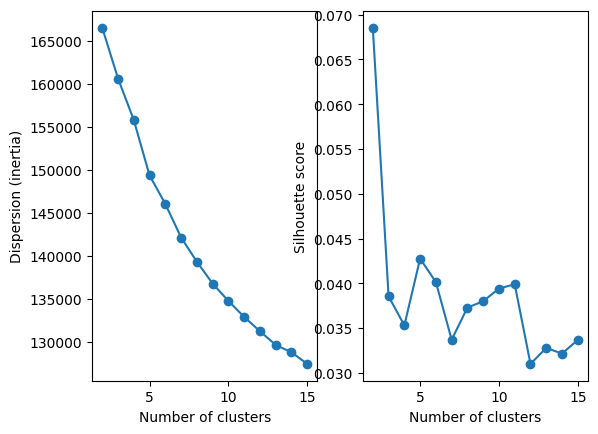

In [191]:
plot_inertia_and_silhouette(behavioral_data_2_st_scl)

In [44]:
kmeans_st_scl = KMeans(n_clusters=2, random_state=42).fit(behavioral_data_2_st_scl)
data_filtered2['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_2_st_scl)
behavioral_data_2['st_scaled_km_cluster2'] = kmeans_st_scl.predict(behavioral_data_2_st_scl)

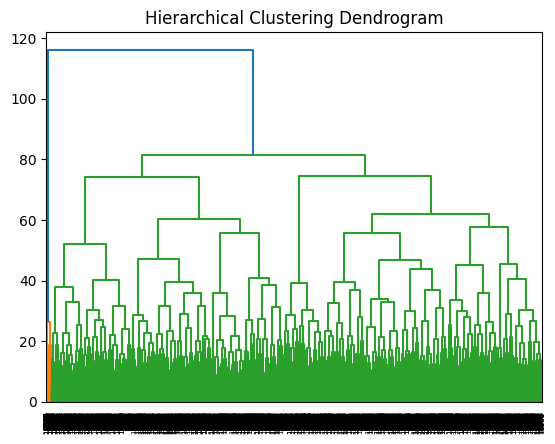

In [193]:
plot_dendrogram(behavioral_data_2_st_scl, 'ward')

In [45]:
data_filtered2['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_st_scl)

behavioral_data_2['st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_st_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Min Max Scaling</h3>

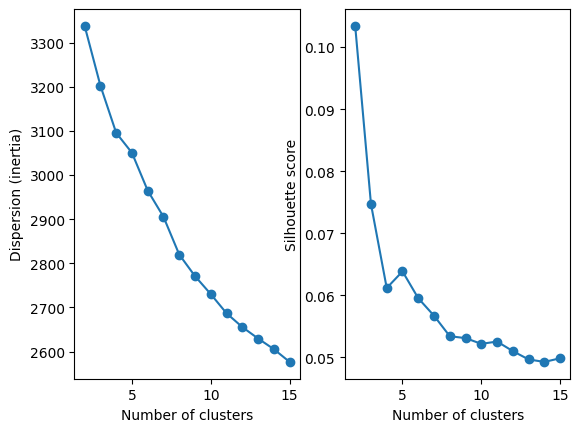

In [195]:
plot_inertia_and_silhouette(behavioral_data_2_mm_scl)

In [46]:
kmeans_mm_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_2_mm_scl)
data_filtered2['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_2_mm_scl)
behavioral_data_2['mm_scaled_km_cluster3'] = kmeans_mm_scl.predict(behavioral_data_2_mm_scl)

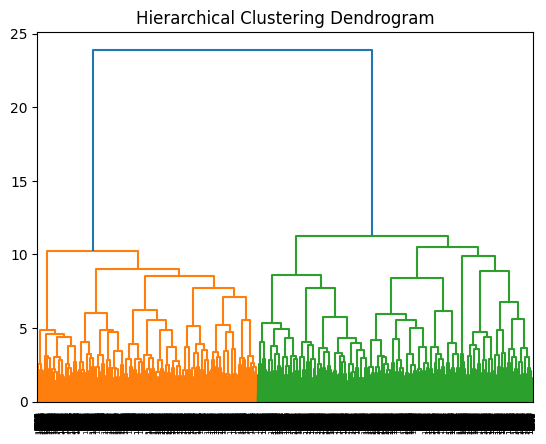

In [197]:
plot_dendrogram(behavioral_data_2_mm_scl, 'ward')

In [47]:
data_filtered2['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_mm_scl)

behavioral_data_2['mm_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_mm_scl)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

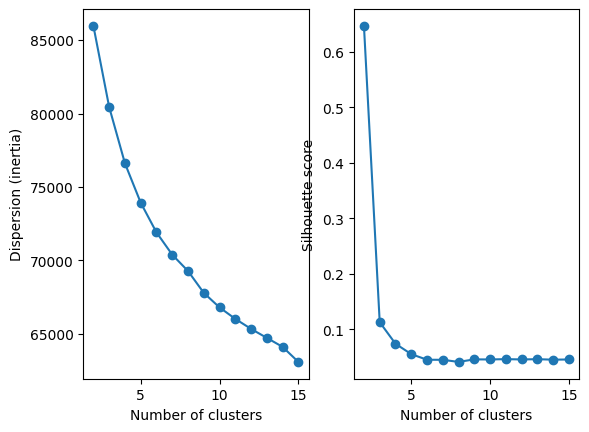

In [199]:
plot_inertia_and_silhouette(behavioral_data_2_rb_scl)

In [48]:
kmeans_rb_scl = KMeans(n_clusters=3, random_state=42).fit(behavioral_data_2_rb_scl)
data_filtered2['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(behavioral_data_2_rb_scl)
behavioral_data_2['rb_scaled_km_cluster3'] = kmeans_rb_scl.predict(behavioral_data_2_rb_scl)

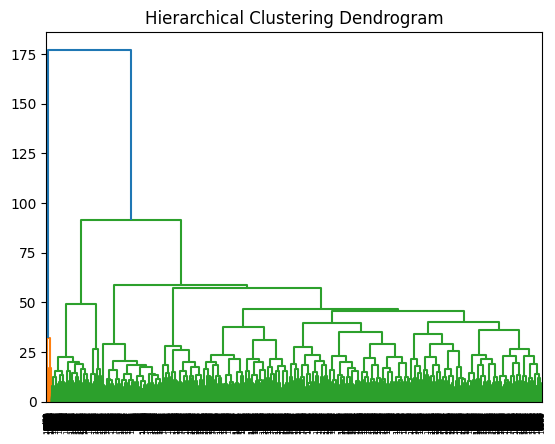

In [201]:
plot_dendrogram(behavioral_data_2_rb_scl, 'ward')

In [49]:
data_filtered2['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_rb_scl)

behavioral_data_2['rb_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(behavioral_data_2_rb_scl)

#### Cluster Visualization 2

In [50]:
cluster_filter1 = ["st_scaled_km_cluster2", "st_scaled_ward_cluster2",
                   'mm_scaled_km_cluster3', "mm_scaled_ward_cluster2",
                   "rb_scaled_km_cluster3", "rb_scaled_ward_cluster2"
                   ]

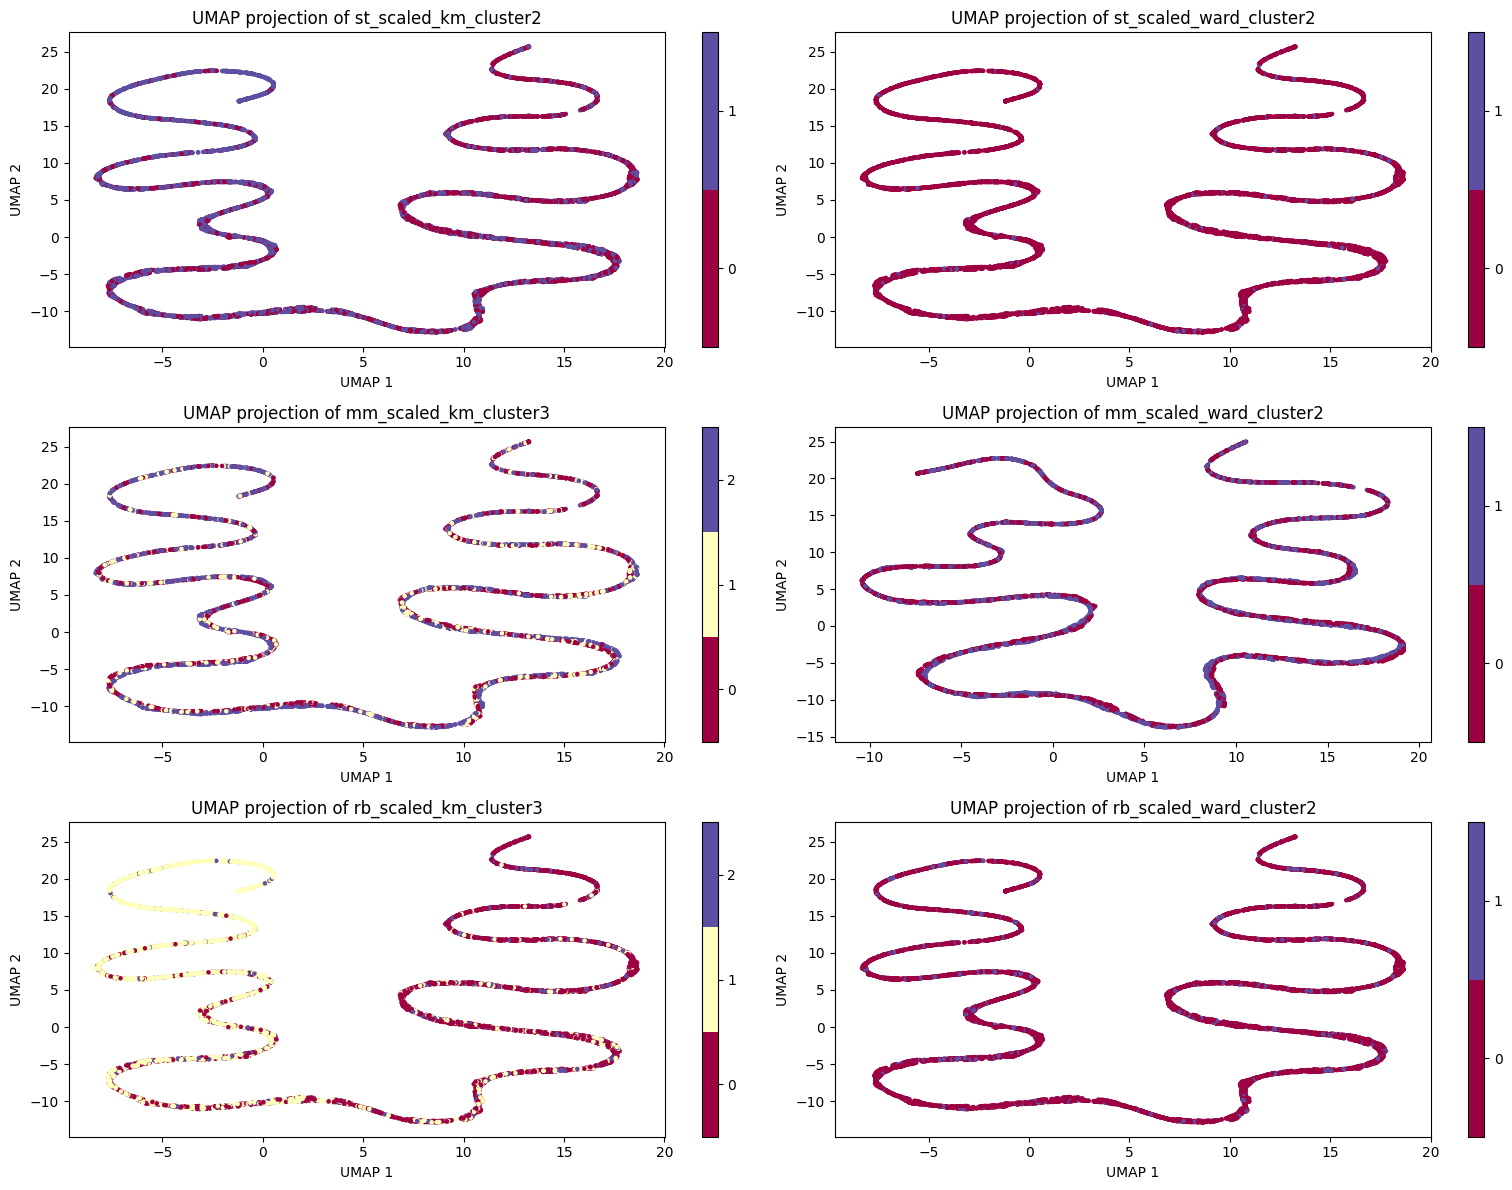

In [51]:
plot_umap_projections(behavioral_data_2, cluster_filter1)

In [52]:
groupby_mean(data_filtered2, 'st_scaled_km_cluster2', n_features= 44)

st_scaled_km_cluster2,0,1
Income,37695.100270,37894.179383
Customer Lifetime Value,7811.560695,8023.736696
EnrollmentType,0.018515,0.015436
rejoined_program,0.000000,0.000000
Days_in_prog,1436.334928,1560.243080
Cancelled_program,0.026420,0.003371
Enrollment_year,2017.556896,2017.220901
Enrollment_month,6.518619,6.569198
Location_cluster,2.407739,2.467353
TotalFlights,183.733326,203.504595


Cluster 0 - Active Redeemers with Off-Season Travel

- Active user of rewards (36.7% points redeemed)

- No Seasonality

Cluster 1 - Holidays travelers

- 14% of their total spend on july, and 10% on june and december


#### Cluster Extraction 3 and 4 

In [53]:
# Filter the DataFrame based on cluster labels
active_redeemers = data_filtered2[data_filtered2['st_scaled_km_cluster2'] == 0]

holiday_travelers = data_filtered2[data_filtered2['st_scaled_km_cluster2'] == 1]

In [54]:
# List of cluster labels to exclude
exclude_clusters = [0,1]

# Filter the original dataset to exclude rows with specified cluster labels
data_filter3 = data_filtered2[~data_filtered2['st_scaled_km_cluster2'].isin(exclude_clusters)]

In [55]:
data_filter3

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,st_scaled_km_cluster2,st_scaled_ward_cluster2,mm_scaled_km_cluster3,mm_scaled_ward_cluster2,rb_scaled_km_cluster3,rb_scaled_ward_cluster2
Loyalty#,,,,,,,,,,,,,,,,,,,,,


# <span style="color:#0097b2">1. Cluster Extraction</span>
[Back to TOC](#toc)

In [222]:
# Define file names for CSV files
file_names = ['../data/behaviour_clusters/no_flights.csv', '../data/behaviour_clusters/new_9_to_12_travelers.csv', 
              '../data/behaviour_clusters/active_redeemers.csv', '../data/behaviour_clusters/holiday_travelers.csv']

# Define dataframes and filenames
datasets = [no_flights, new_9_to_12_travelers, active_redeemers, holiday_travelers]

# Save each subset as a CSV file
for df, file_name in zip(datasets, file_names):
    df.to_csv(file_name)

In [57]:
data['segment'] = 'Unassigned'

data.loc[no_flights.index, 'segment'] = 'No_Flights'
data.loc[new_9_to_12_travelers.index, 'segment'] = 'From_September_to_December_travelers'
data.loc[active_redeemers.index, 'segment'] = 'Active_Redeemers'
data.loc[holiday_travelers.index, 'segment'] = 'Holiday_travelers'

In [58]:
data['segment'].value_counts()

segment
Holiday_travelers                       5636
Active_Redeemers                        4807
From_September_to_December_travelers    4735
No_Flights                              1517
Name: count, dtype: int64

In [59]:
segment_dummies = pd.get_dummies(
    data['segment'],
    prefix='seg',
    dtype=int
)

In [61]:
data = pd.concat([data, segment_dummies], axis=1)

In [62]:
data.drop(columns=['segment'], inplace=True)

In [64]:
data = data.loc[:, ~data.columns.str.startswith(("st_", "mm_", "rb_"))]

In [65]:
data

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single,seg_Active_Redeemers,seg_From_September_to_December_travelers,seg_Holiday_travelers,seg_No_Flights
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,0,0,0,1,0,0,0,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,0,0,0,0,1,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,0,0,0,1,0,0,0,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,0,0,0,1,0,0,0,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,0,0,0,1,0,0,0,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,0,0,0,0,1,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,0,0,0,1,0,0,0,0,1


In [66]:
data.to_csv("../data/behvioral_segment_data.csv")